# Modelos Avanzados de ML para Deteccion de Impago

Objetivo: mejorar las metricas del modelo base (FICO) y del Random Forest usando modelos avanzados de gradient boosting.

**Metricas de referencia (sobre test):**

| Metrica | Modelo Base (FICO) | Random Forest (05_) |
|---|---|---|
| Accuracy | 0.72 | 0.80 |
| AUC-ROC | 0.592 | 0.683 |
| Recall (Default) | 0.24 | 0.02 |
| F1 (Default) | 0.25 | 0.04 |

Modelos a probar: **CatBoost, LightGBM, XGBoost, HistGradientBoosting**

## PASO 1: Carga de datos preprocesados y filtrados

In [1]:
import pickle

# Cargar datos preprocesados y filtrados desde pkl
with open('data/filtered/X_train_filtered.pkl', 'rb') as f:
    X_train_filtered = pickle.load(f)
with open('data/filtered/y_train_filtered.pkl', 'rb') as f:
    y_train = pickle.load(f)
with open('data/filtered/X_test_filtered.pkl', 'rb') as f:
    X_test_filtered = pickle.load(f)
with open('data/filtered/y_test_filtered.pkl', 'rb') as f:
    y_test = pickle.load(f)

print(f"Train filtrado: {X_train_filtered.shape}")
print(f"Test filtrado:  {X_test_filtered.shape}")

Train filtrado: (80000, 163)
Test filtrado:  (20000, 163)


In [2]:
import numpy as np

# Preparar arrays planos
y_train_flat = y_train.values.ravel()
y_test_flat = y_test.values.ravel()

# Calcular scale_pos_weight para modelos que lo necesitan (ratio negativo/positivo)
n_negative = np.sum(~y_train_flat)
n_positive = np.sum(y_train_flat)
scale_pos_weight = n_negative / n_positive
print(f"Clase mayoritaria (Fully Paid): {n_negative}")
print(f"Clase minoritaria (Default):    {n_positive}")
print(f"Ratio (scale_pos_weight):       {scale_pos_weight:.2f}")

Clase mayoritaria (Fully Paid): 63764
Clase minoritaria (Default):    16236
Ratio (scale_pos_weight):       3.93


In [3]:
# Funcion de evaluacion comun para todos los modelos
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt

def evaluate_model(model, X_test, y_test, model_name, results_dict):
    """Evalua un modelo y guarda metricas en results_dict."""
    class_pred = model.predict(X_test)
    prob_pred = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, class_pred)
    prec = precision_score(y_test, class_pred)
    rec = recall_score(y_test, class_pred)
    f1 = f1_score(y_test, class_pred)
    auc = roc_auc_score(y_test, prob_pred)

    results_dict[model_name] = {
        'Accuracy': acc, 'Precision': prec, 'Recall': rec,
        'F1-Score': f1, 'AUC-ROC': auc,
        'prob_pred': prob_pred, 'class_pred': class_pred
    }

    print(f"\n{'='*60}")
    print(f"  {model_name}")
    print(f"{'='*60}")
    print(classification_report(y_test, class_pred,
                                target_names=["Fully Paid", "Default"]))
    print(f"  AUC-ROC: {auc:.4f}")
    return results_dict

# Diccionario para almacenar resultados
results = {}

## PASO 2: Entrenamiento de modelos avanzados

### Por que estos 4 modelos?

CatBoost, LightGBM, XGBoost y HistGradientBoosting son los algoritmos que **mejores resultados
han demostrado en datos tabulares en los ultimos anos**. Multiples benchmarks y competiciones.

Los 4 comparten la filosofia de **gradient boosting** (construir arboles secuencialmente,
donde cada arbol corrige los errores del anterior), pero difieren en implementacion:
- **CatBoost** (Yandex): Ordered Boosting, manejo nativo de categoricas
- **LightGBM** (Microsoft): crecimiento leaf-wise, muy rapido con alta dimensionalidad
- **XGBoost**: el pionero, regularizacion L1/L2 en la funcion objetivo
- **HistGradientBoosting** (sklearn): basado en histogramas, sin dependencias externas

### Estrategia de parametros

No realizamos optimizacion de hiperparametros (grid search, random search, Optuna, etc.).
En su lugar, aplicamos **valores de mejores practicas** ampliamente recomendados en la
literatura y documentacion oficial de cada framework:

| Parametro | Valor | Justificacion |
|---|---|---|
| **learning_rate** | 0.05 | Valor conservador. Rates bajos (0.01-0.1) generalizan mejor que el default (0.1-0.3), a costa de necesitar mas iteraciones |
| **max_depth** | 6-7 | Limita la complejidad de cada arbol. Evita el overfitting severo que vimos con Random Forest (train=1.0). Rango tipico recomendado: 4-8 |
| **min_samples_leaf** | 20 | Evita hojas con muy pocas muestras, que memorizan ruido. Regla general: al menos 20-50 para datasets >10k filas |
| **subsample** | 0.8 | Stochastic gradient boosting: cada arbol ve solo el 80% de los datos, reduciendo varianza (similar al bagging de RF) |
| **colsample_bytree** | 0.8 | Submuestreo de features: cada arbol usa solo el 80% de las columnas, favoreciendo diversidad |
| **reg_alpha / reg_lambda** | 0.1 / 1.0 | Regularizacion L1 y L2 sobre los pesos de las hojas. Penaliza modelos complejos. Valores moderados como punto de partida |
| **class_weight='balanced'** | auto | Asigna pesos inversamente proporcionales a la frecuencia de cada clase (~4x para Default). Esencial con desbalanceo 80/20 |
| **early_stopping** | 50 rounds | Detiene el entrenamiento si la metrica en validacion no mejora en 50 iteraciones, previniendo overfitting |

In [6]:
# split train in train/validation para early stopping
from sklearn.model_selection import train_test_split
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train_filtered, y_train_flat, test_size=0.2, random_state=42, stratify=y_train_flat
)


In [9]:
X_val.shape

(16000, 163)

### 2.1 CatBoost

CatBoost (Yandex) usa **Ordered Boosting** para reducir el sesgo de prediccion y maneja
naturalmente features categoricas. Tiene buena regularizacion por defecto.

Parametros especificos de CatBoost:
- `depth=6`: CatBoost usa arboles simetricos (todas las hojas al mismo nivel), por lo que profundidades bajas (4-8) ya capturan interacciones complejas
- `l2_leaf_reg=3`: regularizacion L2 especifica de CatBoost sobre los valores de las hojas. El default es 3, que es un buen punto de partida
- `auto_class_weights='Balanced'`: equivalente a class_weight='balanced' de sklearn, nativo de CatBoost

In [16]:
from catboost import CatBoostClassifier

catboost_model = CatBoostClassifier(
    iterations=5000,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,              # regularizacion L2
    min_data_in_leaf=20,        # evita hojas con muy pocos datos
    subsample=0.8,              # bagging para reducir varianza
    colsample_bylevel=0.8,      # submuestreo de features por nivel
    auto_class_weights='Balanced',  # compensa desbalanceo
    random_seed=42,
    verbose=200,                # log cada 200 iteraciones
    early_stopping_rounds=50,   # para si no mejora en 50 rondas
    eval_metric='AUC'
)

catboost_model.fit(
    X_train_sub, y_train_sub,
    eval_set=(X_val, y_val),
    verbose=200
)



0:	test: 0.6616540	best: 0.6616540 (0)	total: 13.7ms	remaining: 1m 8s
200:	test: 0.7027935	best: 0.7029626 (198)	total: 2.38s	remaining: 56.8s
400:	test: 0.7052238	best: 0.7052624 (399)	total: 4.75s	remaining: 54.4s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7053553659
bestIteration = 405

Shrink model to first 406 iterations.


CatBoostClassifier(auto_class_weights='Balanced', colsample_bylevel=0.8, depth=6, early_stopping_rounds=50, eval_metric='AUC', iterations=5000, l2_leaf_reg=3, learning_rate=0.05, min_data_in_leaf=20, random_seed=42, subsample=0.8, verbose=200)

In [17]:
results = evaluate_model(catboost_model, X_test_filtered, y_test_flat, "CatBoost", results)


  CatBoost
              precision    recall  f1-score   support

  Fully Paid       0.88      0.68      0.77     16003
     Default       0.33      0.62      0.43      3997

    accuracy                           0.67     20000
   macro avg       0.60      0.65      0.60     20000
weighted avg       0.77      0.67      0.70     20000

  AUC-ROC: 0.7079


### 2.2 LightGBM

LightGBM (Microsoft) usa crecimiento **leaf-wise** (vs level-wise) que converge mas rapido.
Muy eficiente con datasets grandes y features de alta dimensionalidad.

Parametros especificos de LightGBM:
- `num_leaves=63`: en leaf-wise, `num_leaves` es mas importante que `max_depth`. La regla practica es `num_leaves < 2^max_depth` para evitar overfitting. Con depth=7, usamos 63 (< 128)
- `subsample_freq=1`: necesario para que `subsample` se aplique en cada iteracion (si no, se ignora)
- `class_weight='balanced'`: mas estable que `is_unbalance=True` cuando se usa con early stopping, ya que `is_unbalance` puede causar fluctuaciones en la loss que disparan paradas prematuras

In [29]:
from lightgbm import LGBMClassifier
import lightgbm as lgb

lgbm_model = LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=7,
    num_leaves=63,              # 2^6 - 1, conservador para depth=7
    min_child_samples=20,       # minimo de muestras por hoja
    subsample=0.8,
    subsample_freq=1,           # necesario para que subsample se aplique
    colsample_bytree=0.8,
    reg_alpha=0.1,              # regularizacion L1
    reg_lambda=1.0,             # regularizacion L2
    class_weight='balanced',    # mas estable que is_unbalance para early stopping
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgbm_model.fit(
    X_train_sub, y_train_sub,
    eval_set=[(X_val, y_val)],
    eval_metric='auc',
    callbacks=[
        lgb.early_stopping(50, verbose=True),
        lgb.log_evaluation(200)
    ]
)

results = evaluate_model(lgbm_model, X_test_filtered, y_test_flat, "LightGBM", results)

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[109]	valid_0's auc: 0.702451	valid_0's binary_logloss: 0.59976

  LightGBM
              precision    recall  f1-score   support

  Fully Paid       0.88      0.69      0.77     16003
     Default       0.33      0.61      0.43      3997

    accuracy                           0.67     20000
   macro avg       0.60      0.65      0.60     20000
weighted avg       0.77      0.67      0.70     20000

  AUC-ROC: 0.7059


### 2.3 XGBoost

XGBoost fue el primer framework de gradient boosting optimizado. Usa regularizacion L1/L2
directamente en la funcion objetivo y tiene un manejo eficiente de datos dispersos (sparse).

Parametros especificos de XGBoost:
- `min_child_weight=5`: suma minima de la hessiana en una hoja. Valores mayores = arboles mas conservadores. Es el equivalente de XGBoost a `min_samples_leaf`, pero basado en la segunda derivada de la loss
- `gamma=0.1`: reduccion minima de la loss necesaria para hacer un split adicional. Actua como una poda implicita: si un split no mejora la loss en al menos 0.1, no se realiza
- `scale_pos_weight=3.93`: ratio de clases negativa/positiva. Es la forma nativa de XGBoost de manejar desbalanceo (equivalente a class_weight='balanced')

In [21]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=5,         # regularizacion: minimo de hessian por hoja
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,              # L1
    reg_lambda=1.0,             # L2
    gamma=0.1,                  # minimo de reduccion de loss para split
    scale_pos_weight=scale_pos_weight,  # compensa desbalanceo
    random_state=42,
    n_jobs=-1,
    eval_metric='auc',
    early_stopping_rounds=50,
    verbosity=0
)

xgb_model.fit(
    X_train_sub, y_train_sub,
    eval_set=[(X_val, y_val)],
    verbose=200
)

results = evaluate_model(xgb_model, X_test_filtered, y_test_flat, "XGBoost", results)

[0]	validation_0-auc:0.65874
[177]	validation_0-auc:0.70216

  XGBoost
              precision    recall  f1-score   support

  Fully Paid       0.88      0.69      0.77     16003
     Default       0.33      0.61      0.42      3997

    accuracy                           0.67     20000
   macro avg       0.60      0.65      0.60     20000
weighted avg       0.77      0.67      0.70     20000

  AUC-ROC: 0.7045


### 2.4 HistGradientBoosting (sklearn)

Implementacion nativa de sklearn inspirada en LightGBM. Usa histogramas para
discretizar features, lo que lo hace muy rapido. No requiere dependencias externas.

Parametros especificos de HistGradientBoosting:
- `max_leaf_nodes=63`: equivalente a `num_leaves` de LightGBM. Limita el numero de hojas por arbol
- `l2_regularization=1.0`: regularizacion L2 sobre los valores de las hojas. sklearn usa un solo parametro (no L1 separado)
- `validation_fraction=0.1`: usa un 10% del train como validacion interna para el early stopping (no requiere pasar eval_set explicitamente)

In [22]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb_model = HistGradientBoostingClassifier(
    max_iter=1000,
    learning_rate=0.05,
    max_depth=7,
    max_leaf_nodes=63,
    min_samples_leaf=20,
    l2_regularization=1.0,
    class_weight='balanced',
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=50,
    random_state=42,
    verbose=0
)

hgb_model.fit(X_train_filtered, y_train_flat)
print(f"Iteraciones usadas: {hgb_model.n_iter_}")

results = evaluate_model(hgb_model, X_test_filtered, y_test_flat, "HistGradientBoosting", results)

Iteraciones usadas: 152

  HistGradientBoosting
              precision    recall  f1-score   support

  Fully Paid       0.87      0.70      0.77     16003
     Default       0.33      0.60      0.43      3997

    accuracy                           0.68     20000
   macro avg       0.60      0.65      0.60     20000
weighted avg       0.77      0.68      0.70     20000

  AUC-ROC: 0.7037


## PASO 3: Comparacion de modelos

In [23]:
import pandas as pd

# Tabla comparativa de todos los modelos (incluyendo baselines)
metrics_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
comparison = pd.DataFrame({
    name: {m: vals[m] for m in metrics_cols}
    for name, vals in results.items()
}).T

# Anadir baselines
comparison.loc['Baseline FICO'] = [0.72, 0.26, 0.24, 0.25, 0.5921]
comparison.loc['Random Forest (05_)'] = [0.80, 0.5093, 0.0205, 0.0394, 0.6829]

# Ordenar por AUC-ROC descendente
comparison = comparison.sort_values('AUC-ROC', ascending=False)

print("=" * 80)
print("COMPARACION DE MODELOS (ordenados por AUC-ROC)")
print("=" * 80)
comparison.style.format("{:.4f}").highlight_max(axis=0, color='lightgreen')

COMPARACION DE MODELOS (ordenados por AUC-ROC)


,Accuracy,Precision,Recall,F1-Score,AUC-ROC
CatBoost,0.6670,0.3257,0.6222,0.4275,0.7079
LightGBM,0.8023,0.5367,0.0768,0.1344,0.7050
XGBoost,0.6714,0.3267,0.6077,0.4250,0.7045
HistGradientBoosting,0.6763,0.3295,0.5987,0.4250,0.7037
Random Forest (05_),0.8000,0.5093,0.0205,0.0394,0.6829
Baseline FICO,0.7200,0.2600,0.2400,0.2500,0.5921


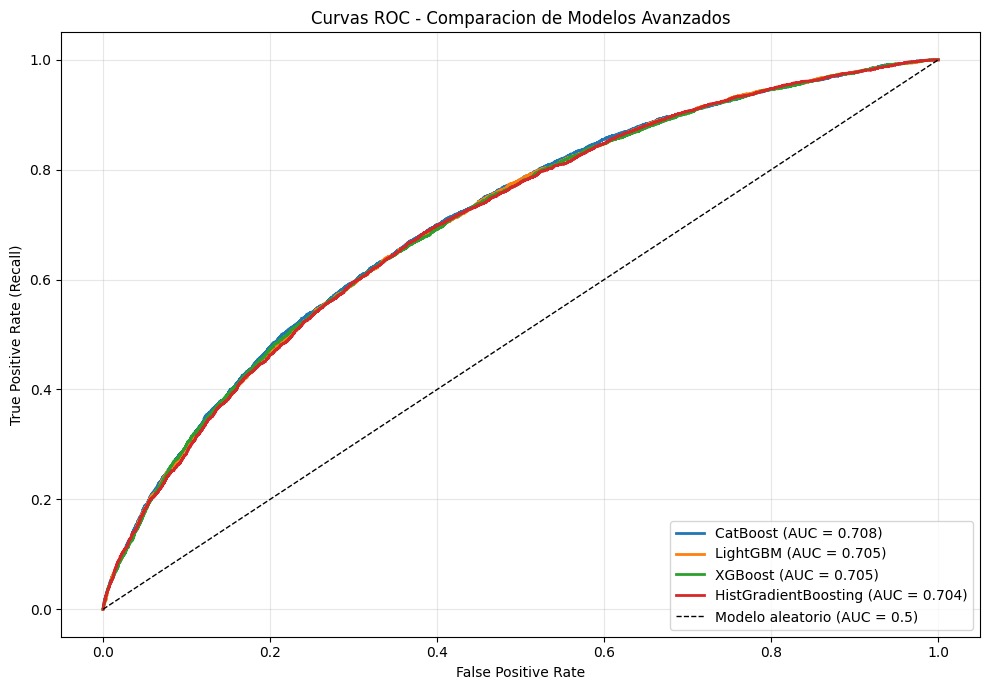

In [24]:
# Curvas ROC de todos los modelos avanzados
plt.figure(figsize=(10, 7))

for name, vals in results.items():
    if 'prob_pred' in vals:
        fpr, tpr, _ = roc_curve(y_test_flat, vals['prob_pred'])
        plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {vals['AUC-ROC']:.3f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1, label="Modelo aleatorio (AUC = 0.5)")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Curvas ROC - Comparacion de Modelos Avanzados')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

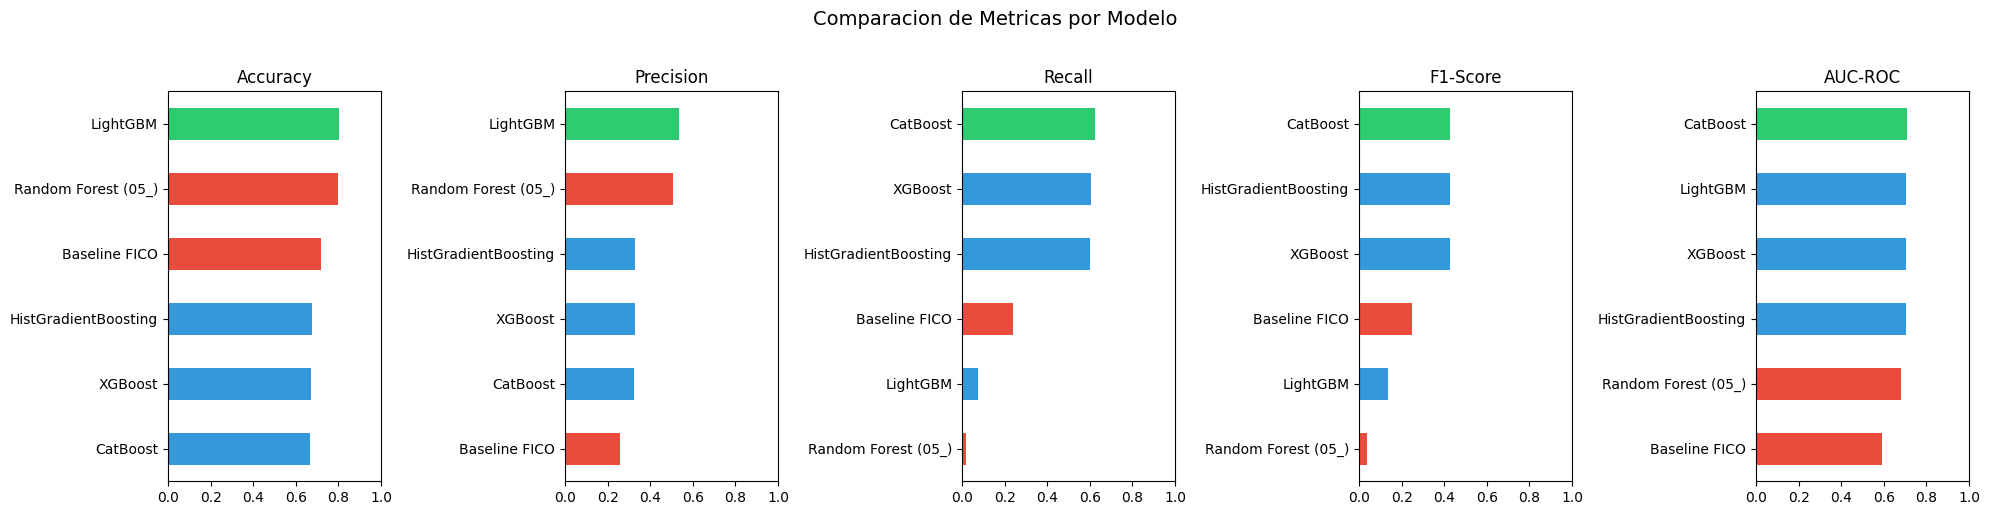

In [25]:
# Grafico de barras comparativo por metrica
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']

for ax, metric in zip(axes, metrics):
    values = comparison[metric].sort_values(ascending=True)
    colors = ['#2ecc71' if v == values.max() else '#3498db' if 'Baseline' not in name and 'Random' not in name else '#e74c3c'
              for name, v in values.items()]
    values.plot(kind='barh', ax=ax, color=colors)
    ax.set_title(metric)
    ax.set_xlim(0, 1)

plt.suptitle('Comparacion de Metricas por Modelo', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## PASO 4: Analisis del mejor modelo y calibracion

Seleccionamos el modelo con mejor AUC-ROC para analisis detallado (matriz de confusion)
y mostramos las curvas de calibracion de **todos** los modelos.

In [26]:
# Identificar el mejor modelo por AUC-ROC
best_name = comparison.index[0]  # ya ordenado descendente por AUC
print(f"Mejor modelo: {best_name} (AUC-ROC = {comparison.loc[best_name, 'AUC-ROC']:.4f})")

# Seleccionar el objeto del modelo
best_models = {
    'CatBoost': catboost_model,
    'LightGBM': lgbm_model,
    'XGBoost': xgb_model,
    'HistGradientBoosting': hgb_model
}
best_model = best_models.get(best_name)
best_probs = results[best_name]['prob_pred']
best_preds = results[best_name]['class_pred']

Mejor modelo: CatBoost (AUC-ROC = 0.7079)


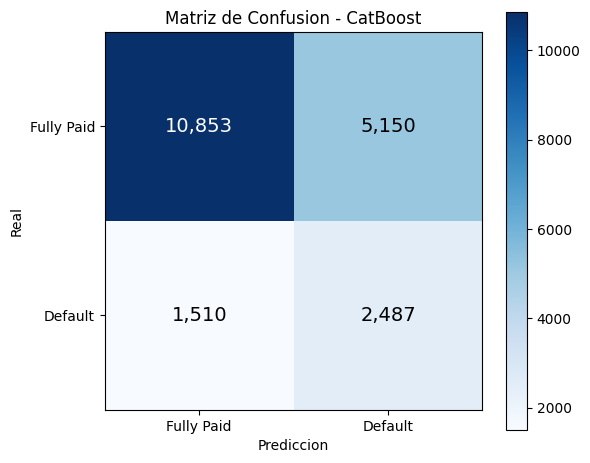


Verdaderos Negativos (TN): 10,853
Falsos Positivos (FP):     5,150
Falsos Negativos (FN):     1,510  <- Defaults no detectados
Verdaderos Positivos (TP): 2,487


In [27]:
# Matriz de confusion del mejor modelo
cm = confusion_matrix(y_test_flat, best_preds)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Fully Paid", "Default"])
ax.set_yticklabels(["Fully Paid", "Default"])
ax.set_xlabel("Prediccion")
ax.set_ylabel("Real")
ax.set_title(f"Matriz de Confusion - {best_name}")

for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=14)

plt.colorbar(im)
plt.tight_layout()
plt.show()

print(f"\nVerdaderos Negativos (TN): {cm[0,0]:,}")
print(f"Falsos Positivos (FP):     {cm[0,1]:,}")
print(f"Falsos Negativos (FN):     {cm[1,0]:,}  <- Defaults no detectados")
print(f"Verdaderos Positivos (TP): {cm[1,1]:,}")

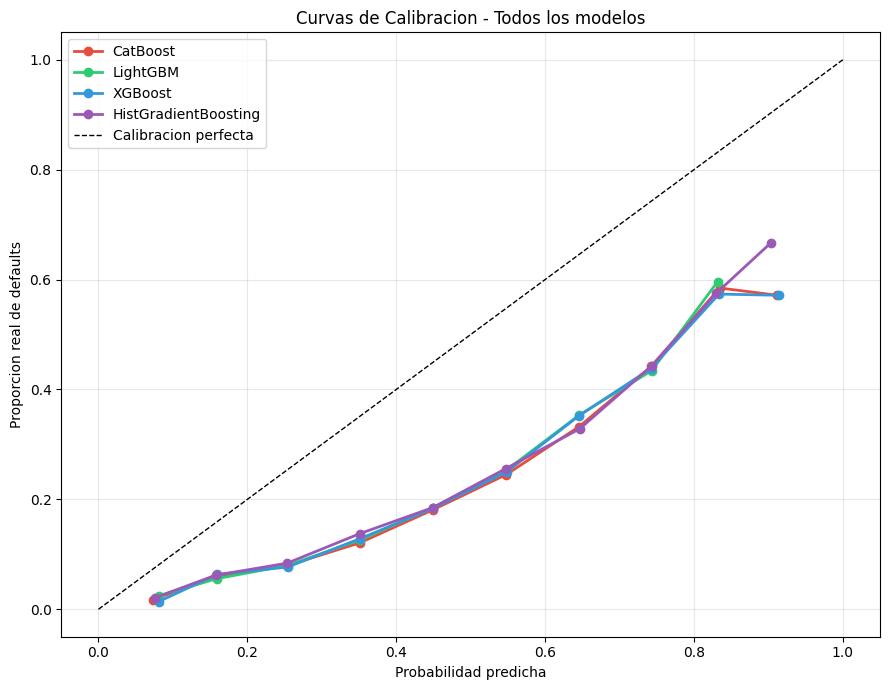

In [30]:
# Curvas de calibracion de TODOS los modelos
from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(9, 7))

colors = {'CatBoost': '#e74c3c', 'LightGBM': '#2ecc71', 'XGBoost': '#3498db', 'HistGradientBoosting': '#9b59b6'}

for name, vals in results.items():
    prob_true, prob_pred_cal = calibration_curve(y_test_flat, vals['prob_pred'], n_bins=10)
    color = colors.get(name, '#333333')
    ax.plot(prob_pred_cal, prob_true, marker='o', lw=2, label=name, color=color)

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Calibracion perfecta')
ax.set_xlabel('Probabilidad predicha')
ax.set_ylabel('Proporcion real de defaults')
ax.set_title('Curvas de Calibracion - Todos los modelos')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Nota sobre la calibracion

Como se observa en las curvas de calibracion, **las probabilidades predichas por los modelos
estan mal calibradas**. Las curvas se alejan significativamente de la diagonal (calibracion
perfecta), lo que significa que cuando un modelo predice, por ejemplo, una probabilidad de
default del 40%, la proporcion real de defaults en ese grupo no es del 40%.

Esto es un problema conocido de los modelos de gradient boosting, especialmente cuando se usa
`class_weight='balanced'` o `scale_pos_weight`: al ponderar mas la clase minoritaria, las
probabilidades predichas se distorsionan (se inflan hacia la clase con mayor peso).

**La calibracion de probabilidades es fundamental en banca**, donde las probabilidades de
default se usan directamente para calcular perdidas esperadas, provisiones y pricing de
credito. Un modelo con buen AUC pero mala calibracion puede ordenar correctamente los
clientes por riesgo, pero las probabilidades absolutas no son fiables.

Este problema lo abordaremos en las **proximas sesiones de clase**.

## PASO 5: Resumen y conclusiones

In [21]:
# Resumen final
print("=" * 80)
print("RESUMEN FINAL - MEJORA SOBRE MODELOS DE REFERENCIA")
print("=" * 80)

best_auc = comparison.loc[best_name, 'AUC-ROC']
best_f1 = comparison.loc[best_name, 'F1-Score']
best_recall = comparison.loc[best_name, 'Recall']

print(f"\nMejor modelo: {best_name}")
print(f"  AUC-ROC:  {best_auc:.4f}  (vs FICO: 0.5921, vs RF: 0.6829)")
print(f"  F1-Score: {best_f1:.4f}  (vs FICO: 0.2500, vs RF: 0.0394)")
print(f"  Recall:   {best_recall:.4f}  (vs FICO: 0.2400, vs RF: 0.0205)")
print()
print(f"  Mejora AUC vs FICO:    +{(best_auc - 0.5921)*100:.2f} pp")
print(f"  Mejora AUC vs RF:      +{(best_auc - 0.6829)*100:.2f} pp")
print(f"  Mejora Recall vs RF:   +{(best_recall - 0.0205)*100:.2f} pp")
print()
print("NOTAS:")
print("  - Los modelos de gradient boosting (CatBoost, LightGBM, XGBoost) son")
print("    superiores al Random Forest porque construyen arboles secuencialmente,")
print("    corrigiendo los errores del arbol anterior (boosting vs bagging).")
print("  - La regularizacion (L1, L2, max_depth, min_samples) controla el overfitting")
print("    que era severo en el RF original (train=1.0 vs test=0.80).")
print("  - El manejo explicito del desbalanceo (class_weight/scale_pos_weight)")
print("    mejora drasticamente el recall de la clase minoritaria (Default).")

RESUMEN FINAL - MEJORA SOBRE MODELOS DE REFERENCIA

Mejor modelo: CatBoost
  AUC-ROC:  0.7088  (vs FICO: 0.5921, vs RF: 0.6829)
  F1-Score: 0.4281  (vs FICO: 0.2500, vs RF: 0.0394)
  Recall:   0.6320  (vs FICO: 0.2400, vs RF: 0.0205)

  Mejora AUC vs FICO:    +11.67 pp
  Mejora AUC vs RF:      +2.59 pp
  Mejora Recall vs RF:   +61.15 pp

NOTAS:
  - Los modelos de gradient boosting (CatBoost, LightGBM, XGBoost) son
    superiores al Random Forest porque construyen arboles secuencialmente,
    corrigiendo los errores del arbol anterior (boosting vs bagging).
  - La regularizacion (L1, L2, max_depth, min_samples) controla el overfitting
    que era severo en el RF original (train=1.0 vs test=0.80).
  - El manejo explicito del desbalanceo (class_weight/scale_pos_weight)
    mejora drasticamente el recall de la clase minoritaria (Default).
